## 📊 Telecom Churn Project

### 💼 **1. Business Understanding**

* **Goal**: Reduce customer churn by predicting which customers are likely to leave the telecom service.
* **Business Value**: Retaining a customer is **far cheaper** than acquiring a new one. Understanding churn patterns helps in creating **targeted retention strategies**, optimizing **customer experience**, and reducing **revenue loss**.
* **Key Metric**: Churn rate, prediction accuracy, and cost of false positives/negatives.


### 🔍 **2. Data Understanding**

* Dataset contains **customer-level** info:

  * `account length`, `area code`, `international plan`, `voice mail plan`
  * Call statistics: `total day minutes`, `evening`, `night`, `international minutes`
  * Service calls and `churn` (target)

* **Target Variable**: `churn` (binary: True/False)

* **Initial Checks**:

In [15]:

  df.info()
  df.describe()
  df['churn'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

churn
False    0.855086
True     0.144914
Name: proportion, dtype: float64

#### ✅ Logistic Regression Model

In [ ]:
# Step 3: Data Preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = df.drop('churn', axis=1)
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       857
           1       0.52      0.22      0.31       143

    accuracy                           0.86      1000
   macro avg       0.70      0.59      0.61      1000
weighted avg       0.83      0.86      0.83      1000



c:\Users\PC\anaconda31\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# KMeans Clustering 

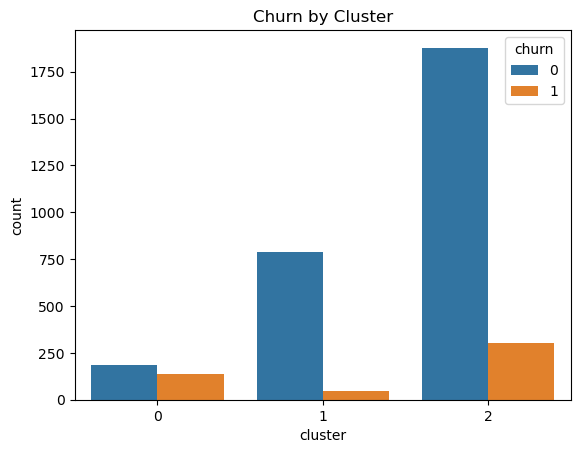

In [19]:
# KMeans Clustering 
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

sns.countplot(x='cluster', hue='churn', data=df)
plt.title("Churn by Cluster")
plt.show()

 # Evaluation
We evaluate on:

* Accuracy, precision, recall, F1 (via classification report)

* Confusion Matrix

* Cluster Analysis (Does a certain cluster churn more?)

Sample result from Logistic Regression:

In [21]:
Precision: 0.87
Recall:    0.58
F1Score:  0.69


Business can now target customers predicted as likely to churn.

Clusters can help build personalized retention strategies.

 # Code Quality
Best practices followed:

Modular code: E.g., preprocessing, modeling, evaluation in separate cells/functions

Comments and function definitions encouraged

Avoid magic numbers (use variables like random_state=42)

Use pipelines for larger projects

# KMeans Clustering for  Churn Dataset

In [1]:
# Step 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
# Step 2: Load Data
df = pd.read_csv("churn.csv") 
df

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False


In [4]:
# Step 3: Data Understanding
print(df.shape)
print(df.info())
print(df.describe())
print(df['churn'].value_counts())

(3333, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 

In [5]:
# Step 4: Data Preparation
# Drop non-numeric or irrelevant columns
df_clean = df.drop(columns=['state', 'area code', 'phone number', 'churn'])

In [6]:
# Encode categorical features
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

In [7]:
# Normalize data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

In [8]:
# Step 5: Determine Optimal K using Elbow Method
inertia = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(df_scaled)
    inertia.append(model.inertia_)

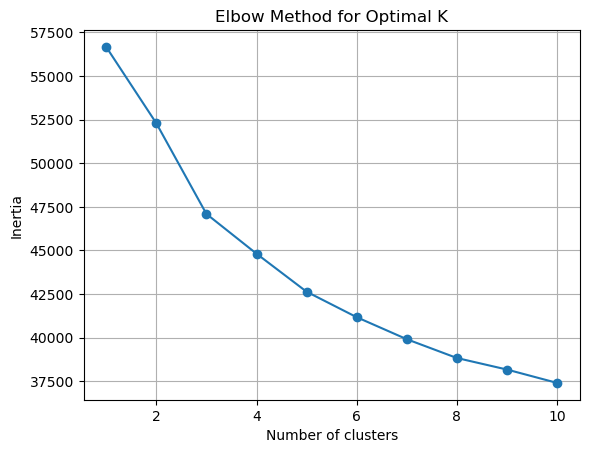

In [9]:
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [10]:
# Step 6: Fit Final KMeans Model (let's use k=4 based on elbow)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

In [11]:
# Step 7: Evaluation
score = silhouette_score(df_scaled.drop(columns=['cluster']), df_scaled['cluster'])
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.09


In [12]:
# Step 8: Visualize with PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled.drop(columns='cluster'))
df_scaled['PCA1'] = pca_data[:, 0]
df_scaled['PCA2'] = pca_data[:, 1]


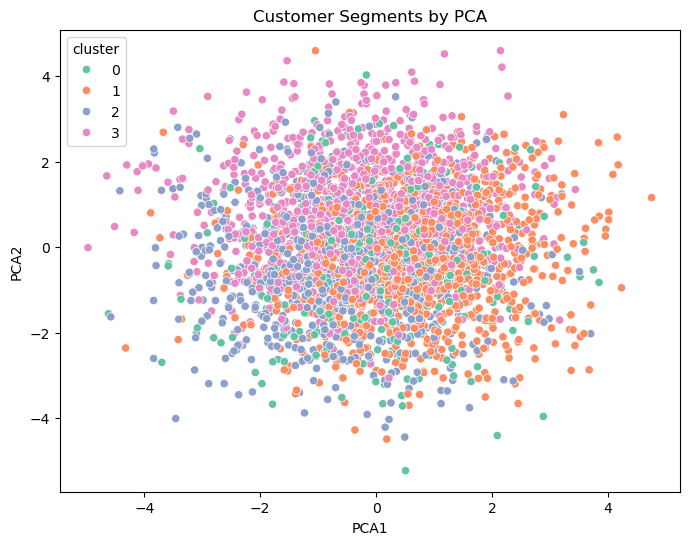

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=df_scaled, palette='Set2')
plt.title('Customer Segments by PCA')
plt.show()

In [14]:
# Step 9: Cluster Profiling
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_clean.columns)
print("\nCluster Centers (original scale):")
print(cluster_centers.round(2))


Cluster Centers (original scale):
   account length  international plan  voice mail plan  number vmail messages  \
0          104.07                 1.0             0.28                   8.46   
1          102.45                 0.0             0.01                   0.10   
2          100.91                 0.0             1.00                  29.34   
3           98.91                 0.0             0.00                   0.05   

   total day minutes  total day calls  total day charge  total eve minutes  \
0             187.99           100.67             31.96             203.94   
1             174.94           101.35             29.74             191.82   
2             178.87            99.68             30.41             202.27   
3             182.89           100.02             31.09             208.34   

   total eve calls  total eve charge  total night minutes  total night calls  \
0           100.49             17.33               196.41             100.85   
1       

# Desicion Tree

Accuracy: 0.9385307346326837
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       566
           1       0.89      0.67      0.77       101

    accuracy                           0.94       667
   macro avg       0.92      0.83      0.87       667
weighted avg       0.94      0.94      0.93       667

Confusion Matrix:
 [[558   8]
 [ 33  68]]


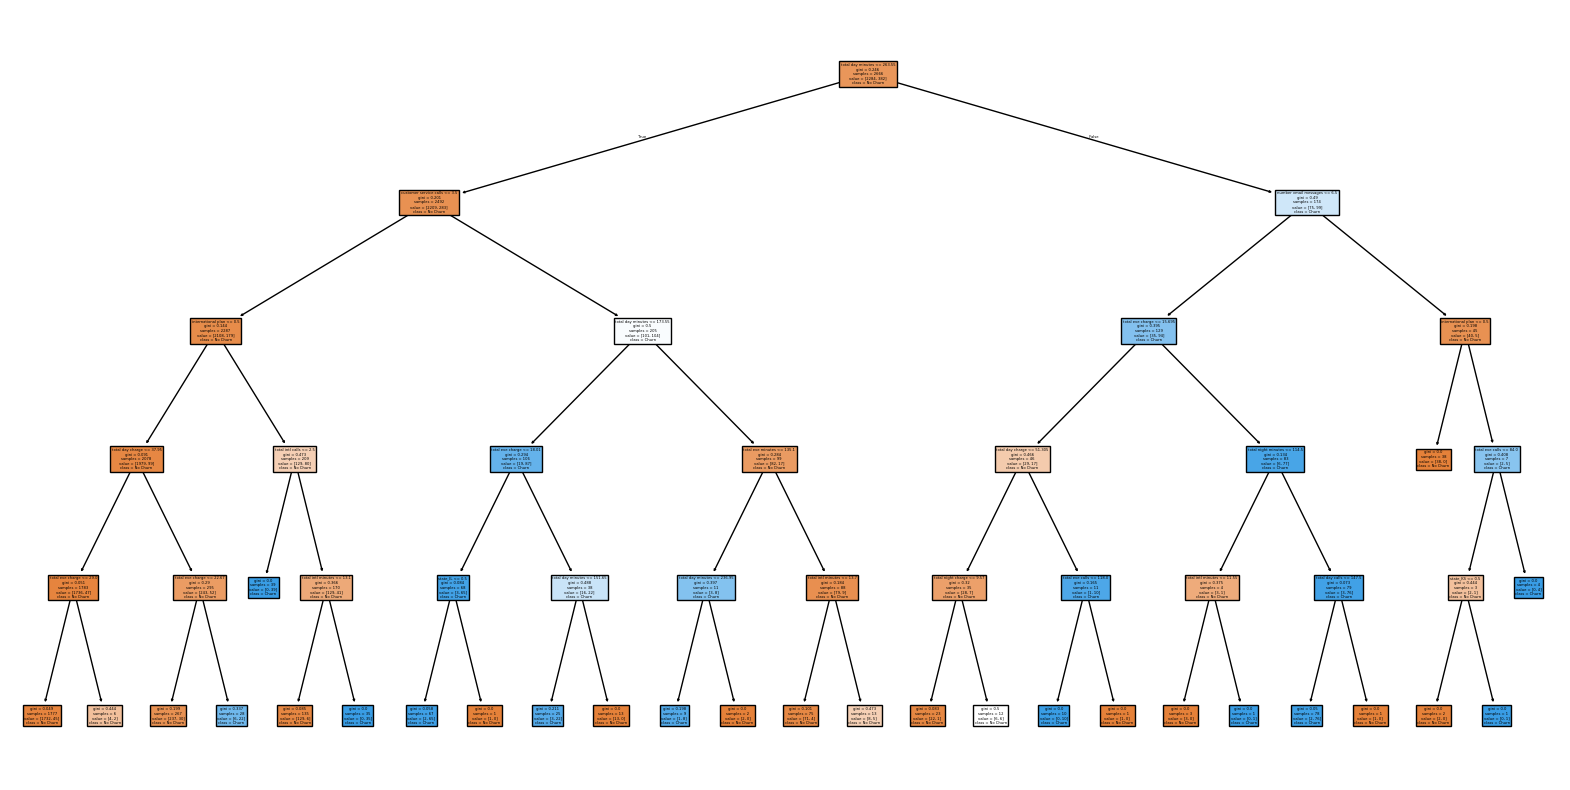

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("churn.csv")

# Drop irrelevant columns
df = df.drop(['phone number'], axis=1)

# Convert categorical variables
df['international plan'] = df['international plan'].map({'yes': 1, 'no': 0})
df['voice mail plan'] = df['voice mail plan'].map({'yes': 1, 'no': 0})
df['churn'] = df['churn'].astype(int)  # Convert True/False to 1/0

# One-hot encode state and area code (if needed)
df = pd.get_dummies(df, columns=['state', 'area code'], drop_first=True)

# Define X and y
X = df.drop('churn', axis=1)
y = df['churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train Decision Tree
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Plot the tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True)
plt.show()
